In [3]:
import pandas as pd
df=pd.read_csv("NFLX.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   str    
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 55.3 KB


In [5]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
std,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06
min,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07


In [9]:
df['Date']=pd.to_datetime(df['Date'])

In [11]:
df['Date']

0      2018-02-05
1      2018-02-06
2      2018-02-07
3      2018-02-08
4      2018-02-09
          ...    
1004   2022-01-31
1005   2022-02-01
1006   2022-02-02
1007   2022-02-03
1008   2022-02-04
Name: Date, Length: 1009, dtype: datetime64[us]

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1009 non-null   datetime64[us]
 1   Open       1009 non-null   float64       
 2   High       1009 non-null   float64       
 3   Low        1009 non-null   float64       
 4   Close      1009 non-null   float64       
 5   Adj Close  1009 non-null   float64       
 6   Volume     1009 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 55.3 KB


In [13]:
df=df.sort_values('Date').reset_index(drop=True)

In [14]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [15]:
print(f"\nDataset starts on: {df['Date'].min()}")
print(f"Dataset ends on: {df['Date'].max()}")


Dataset starts on: 2018-02-05 00:00:00
Dataset ends on: 2022-02-04 00:00:00


In [16]:
df['Tomorrow_Close'] = df['Close'].shift(-1)

In [17]:
df['Target'] = (df['Tomorrow_Close'] > df['Close']).astype(int)

In [18]:
df['Daily_Return'] = df['Close'].pct_change()                         # Daily price change percentage
df['High_Low_Pct'] = (df['High'] - df['Low']) / df['Close']          # How much the price swung today
df['SMA_5'] = df['Close'].rolling(window=5).mean()                    # 5-Day Simple Moving Average
df['SMA_20'] = df['Close'].rolling(window=20).mean()

In [19]:
df = df.dropna()

In [20]:
print("--- NEW DATA PREVIEW WITH FEATURES ---")
print(df[['Date', 'Close', 'Tomorrow_Close', 'Target', 'Daily_Return', 'SMA_5']].head())

--- NEW DATA PREVIEW WITH FEATURES ---
         Date       Close  Tomorrow_Close  Target  Daily_Return       SMA_5
19 2018-03-05  315.000000      325.220001       1      0.046338  297.685999
20 2018-03-06  325.220001      321.160004       0      0.032444  304.608002
21 2018-03-07  321.160004      317.000000       0     -0.012484  310.564002
22 2018-03-08  317.000000      331.440002       1     -0.012953  315.885999
23 2018-03-09  331.440002      321.299988       0      0.045552  321.964001


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
feature_cols = ['Daily_Return', 'High_Low_Pct', 'SMA_5', 'SMA_20', 'Volume']

In [28]:
X=df[feature_cols]
y=df['Target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- SPLIT COMPLETE USING TRAIN_TEST_SPLIT ---")
print(f"Rows used for Training (80%): {X_train.shape[0]}")
print(f"Rows used for Testing (20%): {X_test.shape[0]}")

--- SPLIT COMPLETE USING TRAIN_TEST_SPLIT ---
Rows used for Training (80%): 791
Rows used for Testing (20%): 198


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
predictions = {}
log_reg=LogisticRegression()
log_reg.fit(X_train_scaled,y_train)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
log_preds = log_reg.predict(X_test_scaled)

# 5. Save the predictions to our master dictionary
predictions['Logistic Regression'] = log_preds

# 6. Evaluate the model right now
print("--- LOGISTIC REGRESSION RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, log_preds) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, log_preds))

--- LOGISTIC REGRESSION RESULTS ---
Accuracy: 47.98%

Detailed Report:
              precision    recall  f1-score   support

           0       0.45      0.45      0.45        93
           1       0.51      0.50      0.51       105

    accuracy                           0.48       198
   macro avg       0.48      0.48      0.48       198
weighted avg       0.48      0.48      0.48       198



In [39]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import sklearn

# 1. Turn on the interactive HTML diagram view
sklearn.set_config(display="diagram")

# 2. Initialize the Naive Bayes model
nb_model = GaussianNB()

# 3. Train the model using the scaled training data
nb_model.fit(X_train_scaled, y_train)

# 4. Make predictions on the scaled testing data and save them
nb_preds = nb_model.predict(X_test_scaled)
predictions['Naive Bayes'] = nb_preds

# 5. Evaluate the model right now
print("--- NAIVE BAYES RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, nb_preds) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, nb_preds))
print("\n--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---")

# 6. Display the interactive model box
nb_model

--- NAIVE BAYES RESULTS ---
Accuracy: 49.49%

Detailed Report:
              precision    recall  f1-score   support

           0       0.44      0.28      0.34        93
           1       0.52      0.69      0.59       105

    accuracy                           0.49       198
   macro avg       0.48      0.48      0.47       198
weighted avg       0.48      0.49      0.47       198


--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [40]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import sklearn

# 1. Turn on the interactive HTML diagram view
sklearn.set_config(display="diagram")

# 2. Initialize the SVM model
# We set probability=True so it can calculate the percentage chance of a price movement
svm_model = SVC(kernel='rbf', probability=True, random_state=42)

# 3. Train the model using the scaled training data
svm_model.fit(X_train_scaled, y_train)

# 4. Make predictions on the scaled testing data and save them
svm_preds = svm_model.predict(X_test_scaled)
predictions['Support Vector Machine (SVM)'] = svm_preds

# 5. Evaluate the model right now
print("--- SUPPORT VECTOR MACHINE RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, svm_preds))
print("\n--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---")

# 6. Display the interactive model box
svm_model

--- SUPPORT VECTOR MACHINE RESULTS ---
Accuracy: 57.58%

Detailed Report:
              precision    recall  f1-score   support

           0       0.54      0.62      0.58        93
           1       0.62      0.53      0.57       105

    accuracy                           0.58       198
   macro avg       0.58      0.58      0.58       198
weighted avg       0.58      0.58      0.58       198


--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import sklearn

# 1. Turn on the interactive HTML diagram view
sklearn.set_config(display="diagram")

# 2. Initialize the Decision Tree model
# We set max_depth=5 to prevent the tree from becoming over-complicated
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 3. Train the model using the scaled training data
dt_model.fit(X_train_scaled, y_train)

# 4. Make predictions on the scaled testing data and save them
dt_preds = dt_model.predict(X_test_scaled)
predictions['Decision Tree'] = dt_preds

# 5. Evaluate the model right now
print("--- DECISION TREE RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, dt_preds) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, dt_preds))
print("\n--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---")

# 6. Display the interactive model box
dt_model

--- DECISION TREE RESULTS ---
Accuracy: 56.57%

Detailed Report:
              precision    recall  f1-score   support

           0       0.53      0.67      0.59        93
           1       0.62      0.48      0.54       105

    accuracy                           0.57       198
   macro avg       0.57      0.57      0.56       198
weighted avg       0.58      0.57      0.56       198


--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import sklearn

# 1. Turn on the interactive HTML diagram view
sklearn.set_config(display="diagram")

# 2. Initialize the Random Forest model
# n_estimators=100 means we are building a forest of 100 individual trees
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# 3. Train the model using the scaled training data
rf_model.fit(X_train_scaled, y_train)

# 4. Make predictions on the scaled testing data and save them
rf_preds = rf_model.predict(X_test_scaled)
predictions['Random Forest'] = rf_preds

# 5. Evaluate the model right now
print("--- RANDOM FOREST RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, rf_preds))
print("\n--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---")

# 6. Display the interactive model box
rf_model

--- RANDOM FOREST RESULTS ---
Accuracy: 58.59%

Detailed Report:
              precision    recall  f1-score   support

           0       0.55      0.70      0.61        93
           1       0.65      0.49      0.55       105

    accuracy                           0.59       198
   macro avg       0.60      0.59      0.58       198
weighted avg       0.60      0.59      0.58       198


--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [43]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import sklearn

# 1. Turn on the interactive HTML diagram view
sklearn.set_config(display="diagram")

# 2. Initialize the KNN model
# n_neighbors=7 means it will look at the 7 closest historical days to make a decision
knn_model = KNeighborsClassifier(n_neighbors=7)

# 3. Train the model using the scaled training data
knn_model.fit(X_train_scaled, y_train)

# 4. Make predictions on the scaled testing data and save them
knn_preds = knn_model.predict(X_test_scaled)
predictions['K-Nearest Neighbors (KNN)'] = knn_preds

# 5. Evaluate the model right now
print("--- K-NEAREST NEIGHBORS RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, knn_preds) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, knn_preds))
print("\n--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---")

# 6. Display the interactive model box
knn_model

--- K-NEAREST NEIGHBORS RESULTS ---
Accuracy: 52.02%

Detailed Report:
              precision    recall  f1-score   support

           0       0.49      0.61      0.55        93
           1       0.56      0.44      0.49       105

    accuracy                           0.52       198
   macro avg       0.53      0.53      0.52       198
weighted avg       0.53      0.52      0.52       198


--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [46]:
!pip install xgboost

In [47]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import sklearn

# 1. Turn on the interactive HTML diagram view
sklearn.set_config(display="diagram")

# 2. Initialize the XGBoost model
# n_estimators=100 means 100 trees will be built in sequence
# learning_rate=0.05 controls how aggressively each tree corrects the previous one's mistakes
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)

# 3. Train the model using the scaled training data
xgb_model.fit(X_train_scaled, y_train)

# 4. Make predictions on the scaled testing data and save them
xgb_preds = xgb_model.predict(X_test_scaled)
predictions['XGBoost'] = xgb_preds

# 5. Evaluate the model right now
print("--- XGBOOST RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, xgb_preds))
print("\n--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---")

# 6. Display the interactive model box
xgb_model

--- XGBOOST RESULTS ---
Accuracy: 57.58%

Detailed Report:
              precision    recall  f1-score   support

           0       0.54      0.70      0.61        93
           1       0.64      0.47      0.54       105

    accuracy                           0.58       198
   macro avg       0.59      0.58      0.57       198
weighted avg       0.59      0.58      0.57       198


--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [48]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
import sklearn

# 1. Turn on the interactive HTML diagram view
sklearn.set_config(display="diagram")

# 2. Initialize the AdaBoost model
# n_estimators=100 means we will link 100 decision stumps together
# Using default base estimator (DecisionTreeClassifier with max_depth=1)
ada_model = AdaBoostClassifier(n_estimators=100, random_state=42)

# 3. Train the model using the scaled training data
ada_model.fit(X_train_scaled, y_train)

# 4. Make predictions on the scaled testing data and save them
ada_preds = ada_model.predict(X_test_scaled)
predictions['AdaBoost'] = ada_preds

# 5. Evaluate the model right now
print("--- ADABOOST RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, ada_preds) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, ada_preds))
print("\n--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---")

# 6. Display the interactive model box
ada_model

--- ADABOOST RESULTS ---
Accuracy: 54.55%

Detailed Report:
              precision    recall  f1-score   support

           0       0.51      0.74      0.61        93
           1       0.62      0.37      0.46       105

    accuracy                           0.55       198
   macro avg       0.57      0.56      0.53       198
weighted avg       0.57      0.55      0.53       198


--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---


,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [49]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report
import sklearn
import pandas as pd

# 1. Turn on the interactive HTML diagram view
sklearn.set_config(display="diagram")

# 2. Extract the actual closing prices for the training and testing sets
# (We need the raw dollar figures, not the 1s and 0s)
y_train_price = df['Tomorrow_Close'].iloc[:X_train.shape[0]]
current_prices_test = df['Close'].iloc[X_train.shape[0]:].values

# 3. Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_price)

# 4. Predict tomorrow's actual dollar price
lr_predicted_prices = lr_model.predict(X_test_scaled)

# 5. Convert the dollar predictions into 1s (UP) and 0s (DOWN)
lr_preds = (lr_predicted_prices > current_prices_test).astype(int)
predictions['Linear Regression'] = lr_preds

# 6. Evaluate the converted predictions
print("--- LINEAR REGRESSION RESULTS ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds) * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, lr_preds))
print("\n--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---")

# 7. Display the interactive model box
lr_model

--- LINEAR REGRESSION RESULTS ---
Accuracy: 52.02%

Detailed Report:
              precision    recall  f1-score   support

           0       0.49      0.53      0.51        93
           1       0.55      0.51      0.53       105

    accuracy                           0.52       198
   macro avg       0.52      0.52      0.52       198
weighted avg       0.52      0.52      0.52       198


--- INTERACTIVE MODEL VIEW (Click arrows below to expand) ---


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd

# 1. Create an empty list to store the metrics for each model
scorecard_data = []

# 2. Loop through our predictions dictionary and calculate scores
for model_name, preds in predictions.items():
    accuracy = accuracy_score(y_test, preds) * 100
    precision = precision_score(y_test, preds, zero_division=0) * 100
    recall = recall_score(y_test, preds, zero_division=0) * 100
    
    # Append the results as a dictionary
    scorecard_data.append({
        'Model Name': model_name,
        'Accuracy (%)': round(accuracy, 2),
        'Precision (%)': round(precision, 2),
        'Recall (%)': round(recall, 2)
    })

# 3. Convert the list into a beautiful Pandas DataFrame
scorecard_df = pd.DataFrame(scorecard_data)

# 4. Sort the table by Accuracy so the best model is at the very top!
scorecard_df = scorecard_df.sort_values(by='Accuracy (%)', ascending=False).reset_index(drop=True)

# 5. Display the final leaderboard
print("--- THE FINAL MACHINE LEARNING LEADERBOARD ---")
scorecard_df

--- THE FINAL MACHINE LEARNING LEADERBOARD ---


,Model Name,Accuracy (%),Precision (%),Recall (%)
0,Random Forest,58.59,64.56,48.57
1,XGBoost,57.58,63.64,46.67
2,Support Vector Machine (SVM),57.58,61.54,53.33
3,Decision Tree,56.57,61.73,47.62
4,AdaBoost,54.55,61.90,37.14
5,Linear Regression,52.02,55.10,51.43
6,K-Nearest Neighbors (KNN),52.02,56.10,43.81
7,Naive Bayes,49.49,51.80,68.57
8,Logistic Regression,47.98,50.96,50.48


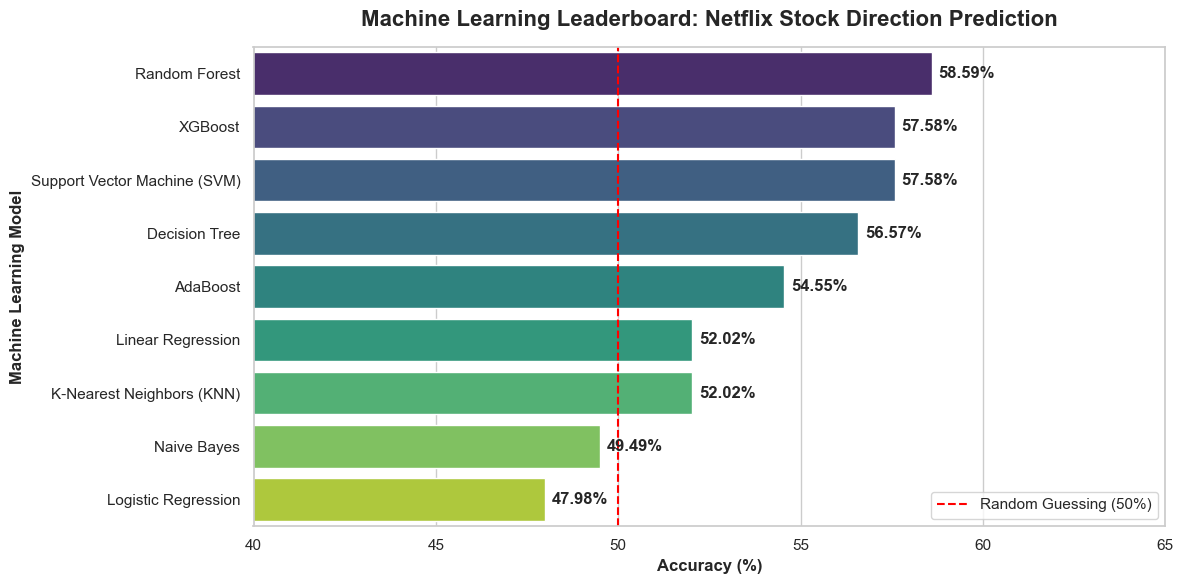

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the visual style of the plot
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 2. Create a horizontal bar chart sorted by Accuracy
ax = sns.barplot(
    x="Accuracy (%)", 
    y="Model Name", 
    data=scorecard_df, 
    palette="viridis",
    hue="Model Name",
    legend=False
)

# 3. Add the exact accuracy numbers on top of each bar so it's easy to read
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=5, weight='bold')

# 4. Add a baseline marker at 50% (which represents a random coin flip)
plt.axvline(50, color='red', linestyle='--', linewidth=1.5, label='Random Guessing (50%)')

# 5. Customize titles and label
plt.title("Machine Learning Leaderboard: Netflix Stock Direction Prediction", fontsize=16, weight='bold', pad=15)
plt.xlabel("Accuracy (%)", fontsize=12, weight='bold')
plt.ylabel("Machine Learning Model", fontsize=12, weight='bold')
plt.xlim(40, 65) # Zoom in on the relevant accuracy range
plt.legend(loc="lower right")

# 6. Show the final polished chart
plt.tight_layout()
plt.show()

In [52]:
import joblib

# 1. Save the winning Random Forest model to a file
joblib.dump(rf_model, 'netflix_rf_model.pkl')

# 2. Save the scaler too! (Remember, website inputs MUST be scaled exactly like the training data)
joblib.dump(scaler, 'data_scaler.pkl')

print("Model and Scaler successfully saved to your computer!")

Model and Scaler successfully saved to your computer!


In [53]:
!pip install streamlit

   ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.3 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/10.3 MB 1.4 MB/s eta 0:00:08
   ---- ----------------------------------- 1.0/10.3 MB 1.3 MB/s eta 0:00:07
   ---- ----------------------------------- 1.0/10.3 MB 1.3 MB/s eta 0:00:07
   ----- ---------------------------------- 1.3/10.3 MB 1.0 MB/s eta 0:00:09
   ------ --------------------------------- 1.6/10.3 MB 1.1 MB/s eta 0:00:09
   ------- -------------------------------- 1.8/10.3 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/10.3 MB 1.1 MB/s eta 0:00:08
   -------- ------------------------------- 2.1/10.3 MB 1.0 MB/s eta 0:00:08
   --------- ------------------------------ 2.4/10.3 MB 1.0 MB/s eta 0:00:08
   ---------- ----------------------------- 2.6/10.3 MB 1.1 MB/s eta 0:00:08
   ----------